# P3 프로젝트: 캘리포니아 주택가격

P3 실습에서는 삶의 만족도 데이터를 이용하여
**경사하강법이 손실을 줄이면서 절편과 기울기를 조금씩 수정하는 과정**을 살펴보았다.

이번 프로젝트에서는 사이킷런의 캘리포니아 주택 데이터를 이용하여
같은 원리를 실제 다변량 회귀 문제로 확장한다.

핵심 질문은 다음과 같다.

> **특성의 크기와 분포는 `SGDRegressor`의 경사하강법 학습에 어떤 영향을 주는가?**

다음 세 가지 입력을 같은 `SGDRegressor` 설정으로 비교한다.

1. 원본 특성
2. 표준화한 특성
3. 로그 변환 후 표준화한 특성

분석의 초점은 단순히 RMSE가 가장 작은 모델을 찾는 것이 아니라,
**왜 경사하강법의 학습 결과가 달라지는지 설명하는 것**이다.

**코드 실행**

[(구글 코랩) P3 프로젝트: 캘리포니아 주택가격](https://colab.research.google.com/github/codingalzi/code-workout-ml/blob/master/p3_project_california_housing.ipynb)에서 코드를 실행할 수 있다.

**프로젝트 진행 원칙**

1. 학습용·검증용·최종 테스트용 데이터를 구분한다.
2. 세 실험에서 같은 `SGDRegressor` 설정과 같은 학습률을 사용한다.
3. 같은 에포크 수만큼 학습하여 입력 데이터의 변화가 학습에 미치는 영향을 비교한다.
4. 모델과 전처리 선택은 검증 데이터에서 수행한다.
5. 최종 테스트 데이터는 마지막 평가에서만 사용한다.
6. AI는 코드와 해석을 검토하는 도구로 사용할 수 있지만, 중요한 판단에는 자신의 근거를 남긴다.

**환경설정**

In [27]:
import sys
import sklearn
from packaging.version import Version

assert sys.version_info >= (3, 10)
assert Version(sklearn.__version__) >= Version("1.6.1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rc("font", size=12)
plt.rc("axes", labelsize=13, titlesize=13)
plt.rc("legend", fontsize=11)

## 1단계 — 데이터 이해와 학습 가설

### 캘리포니아 주택 데이터를 불러온다

이번 프로젝트에서는 `fetch_california_housing()`이 제공하는 데이터를 사용한다.

[P1 실습: 머신러닝 프로젝트](https://codingalzi.github.io/code-workout-ml/p1-lab-end2end-ml-project/)에서
사용한 데이터와는 다르게 
해안 근접도 특성이 없으며 결측치도 전혀 없다.

즉, 모든 입력 특성이 수치형이고 결측치가 없으므로,
범주형 인코딩이나 결측치 처리는 필요하지 않다.

In [28]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

X = housing.data.copy()
y = housing.target.copy()

print("입력 데이터 크기:", X.shape)
print("타깃 데이터 크기:", y.shape)

X.head()

입력 데이터 크기: (20640, 8)
타깃 데이터 크기: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


타깃 `MedHouseVal`은 지역의 중간 주택 가격을 나타내며 단위는 **10만 달러**이다.

In [29]:
y.describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

데이터에 결측치가 없는지 확인한다.

In [30]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


### 학습용·검증용·최종 테스트용으로 나눈다

전체 데이터의 약 60%는 학습용, 20%는 검증용, 20%는 최종 테스트용으로 사용한다.

최종 테스트 데이터는 모델과 전처리 선택이 끝날 때까지 사용하지 않는다.

In [31]:
from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(X, y, 
                                                test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, 
                                                  test_size=0.25, random_state=42)

print("학습용:", X_train.shape)
print("검증용:", X_val.shape)
print("최종 테스트용:", X_test.shape)

학습용: (12384, 8)
검증용: (4128, 8)
최종 테스트용: (4128, 8)


### **특성들의 크기를 확인한다**

이번 프로젝트에서 사용하는 캘리포니아 주택가격 데이터에는 다음과 같은 8개의 입력 특성이 있다.

- `MedInc`: 지역의 중간 소득
- `HouseAge`: 주택의 중간 연령
- `AveRooms`: 가구당 평균 방 수
- `AveBedrms`: 가구당 평균 침실 수
- `Population`: 지역 인구
- `AveOccup`: 가구당 평균 거주 인원
- `Latitude`: 위도
- `Longitude`: 경도

P3 실습에서는 **1인당 GDP 하나만** 입력 특성으로 사용했다.  
따라서 하나의 가중치가 어떻게 변하는지 비교적 쉽게 살펴볼 수 있었다.

이번에는 8개 특성을 동시에 사용하므로 각 특성에 대응하는 가중치도 함께 학습해야 한다.

$$ \hat y = w_0 + w_1x_1 + w_2x_2 + \cdots + w_8x_8 $$

그런데 캘리포니아 주택가격 데이터의 특성들은 **값의 크기가 서로 매우 다르다.**

예를 들어 `MedInc`는 대부분 한 자릿수 정도의 값을 가지지만,
`Population`은 수백이나 수천, 경우에 따라 수만에 이르는 값을 가질 수 있다.

`Latitude`와 `Longitude`도 `MedInc`나 `AveRooms`와는 전혀 다른 단위를 사용한다.

먼저 실제 훈련 데이터에서 각 특성의 값이 어느 정도 범위에 있는지 확인해 보자.

In [32]:
X_train.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,12384.000000,12384.000000,12384.000000,12384.000000,12384.000000,12384.000000,12384.000000,12384.000000
mean,3.870090,28.585837,5.411837,1.092586,1427.289648,3.033264,35.642003,-119.579831
std,1.888237,12.608072,2.077484,0.361947,1140.978664,7.074410,2.130977,2.005077
min,0.499900,1.000000,0.888889,0.375000,3.000000,0.692308,32.560000,-124.350000
25%,2.562500,18.000000,4.443167,1.006263,790.000000,2.427379,33.930000,-121.800000
50%,3.552100,29.000000,5.223123,1.049628,1170.000000,2.816215,34.260000,-118.500000
75%,4.740400,37.000000,6.046054,1.100524,1726.000000,3.280020,37.720000,-118.010000
max,15.000100,52.000000,61.812500,11.410714,35682.000000,599.714286,41.950000,-114.310000


표를 보면 특성마다 최솟값, 최댓값, 평균, 표준편차의 크기가 상당히 다르다는 것을 확인할 수 있다.

특히 `Population`처럼 값이 큰 특성과 `MedInc`, `AveRooms`처럼 상대적으로 값이 작은 특성을 비교해 보자.

왜 이런 차이가 `SGDRegressor`에서 중요할까?

SGD는 예측값과 실제값의 차이를 이용하여 각 특성의 가중치를 조금씩 수정한다.

제곱 오차를 사용하는 선형 회귀에서 특성 $x_j$에 대응하는 가중치 $w_j$의 gradient는 개념적으로 다음과 연결된다.

$$ \text{gradient}_j \propto (\hat y-y)x_j $$

여기서

- $\hat y-y$는 **예측 오차**
- $x_j$는 해당 특성의 값
- $\text{gradient}_j$는 가중치 $w_j$를 어느 방향으로 얼마나 수정할지를 결정하는 값

이다.
단, $\propto$는 비례한다의 의미이다.

따라서 **예측 오차가 같더라도 특성값이 크면 gradient도 커질 수 있다.**

예를 들어 어느 두 특성에서 현재 예측 오차가 똑같이 `1`이라고 가정해 보자.

어떤 지역에서

- `MedInc`가 약 `4`
- `Population`이 약 `3000`

이라면, 매우 단순화해서 생각했을 때 gradient에 반영되는 크기는 다음처럼 크게 달라질 수 있다.

$$ 1\times4=4 $$

$$ 1\times3000=3000 $$

즉 같은 예측 오차가 있어도 `Population`처럼 값이 큰 특성은
그에 대응하는 가중치의 gradient를 훨씬 크게 만들 수 있다.

SGD는 이 gradient를 이용하여 가중치를 다음과 같이 수정한다.

$$ w_j \leftarrow w_j-\eta\,\text{gradient}_j $$

여기서 $\eta$는 **학습률**(learning rate)이다.

모든 가중치에 같은 학습률을 사용하더라도
gradient의 크기가 크게 다르면 어떤 가중치는 조금만 변하는 반면
다른 가중치는 한 번에 지나치게 크게 변할 수 있다.

특히 `Population`처럼 큰 값을 가진 특성 때문에 가중치가 너무 크게 변하면
새로운 예측값도 지나치게 커질 수 있다.

그러면 다음과 같은 현상이 반복될 수 있다.

> **큰 특성값 → 큰 gradient → 큰 가중치 업데이트 → 큰 예측 오차 → 더 큰 gradient**

이 과정이 계속되면 손실이 감소하지 않고 오히려 매우 크게 증가할 수 있다.

이를 **발산**(divergence)이라고 한다.

따라서 전처리 없이 `SGDRegressor`를 훈련하기 전에,
캘리포니아 주택가격 데이터의 특성들이 얼마나 서로 다른 크기를 가지는지 확인하는 것이 중요하다.

:::{important}
`Population`의 값이 `MedInc`보다 크다고 해서 `Population`이 주택가격 예측에 더 중요한 특성이라는 뜻은 아니다.

여기서 비교하는 것은 **특성의 중요도**가 아니라 **특성값의 크기**다.

이번 단계에서는 이러한 크기 차이가 경사하강법의 gradient와 가중치 업데이트에 어떤 영향을 주는지를 확인한다.
:::

### 프로젝트 기록 ① — 분석 설계

다음을 자신의 말로 작성한다.

- **예측 대상**:
- **회귀 문제라고 판단한 이유**:
- **평가 지표로 RMSE를 사용하는 이유**:
- P3 실습의 단순 선형 회귀와 이번 다변량 회귀의 가장 큰 차이:
- 이번 프로젝트에서 확인하려는 핵심 질문:

### 프로젝트 기록 ② — 특성 크기와 학습 가설

`X_train.describe()`를 보고 작성한다.

- 값의 범위가 가장 큰 특성:
- 값의 범위가 비교적 작은 특성:
- 특성들의 크기가 서로 크게 다른가?:
- 이런 차이가 `gradient`에 어떤 영향을 줄 것으로 예상하는가?:
- **전처리 없이 SGD를 실행하면 어떤 일이 생길지 자신의 가설을 작성한다.**

> 나의 가설:

### AI 체크포인트 ① — 학습 가설 검토

AI에게 특성별 범위와 자신의 가설을 보여 주고 검토를 요청해도 된다.

다음은 직접 확인한다.

- 특성의 **크기**와 특성의 **중요도**를 같은 의미로 해석하지 않았는가?
- 큰 특성값이 gradient 크기에 영향을 줄 수 있다는 설명이 맞는가?
- 아직 실행하지 않은 결과를 이미 알고 있는 것처럼 단정하지 않았는가?

**수정하거나 받아들이지 않은 AI의 제안과 그 이유**

> 작성:

### 1단계 마무리 체크

다음을 설명할 수 있는지 확인한다.

- 회귀 문제와 RMSE의 의미
- 학습용·검증용·테스트 데이터를 나누는 이유
- 여러 특성을 사용하는 선형 회귀에서는 여러 가중치를 학습한다는 점
- 특성의 크기가 SGD의 gradient와 파라미터 업데이트에 영향을 줄 수 있는 이유

## 2단계 — 경사하강법의 학습 과정을 비교한다

### 배치 경사하강법에서 SGD로 확장한다

P3 실습에서는 한 번의 파라미터 업데이트에 전체 데이터를 사용했다.
이를 **배치 경사하강법**이라고 했다.

`SGDRegressor`의 SGD는 **확률적 경사하강법**(Stochastic Gradient Descent)을 뜻한다.

SGD에서는 하나의 샘플을 이용할 때마다 파라미터를 조금씩 업데이트한다.

> **샘플 → 예측 → 오차 → gradient → 파라미터 업데이트**

훈련 데이터 전체를 한 번 사용하면 **1 epoch**가 끝난다.

이번 프로젝트에서는 `partial_fit()`을 반복 호출하여
에포크가 진행될 때 검증 RMSE가 어떻게 변하는지 직접 관찰한다.

### 비교에 사용할 SGD 설정을 고정한다

이번 프로젝트에서는 전처리의 영향을 분명하게 보기 위해
세 실험에서 다음 설정을 동일하게 사용한다.

- 손실 함수: squared error
- 규제: 사용하지 않음
- 학습률 방식: constant
- 학습률: `0.0001`
- 에포크 수: 20

학습률 자체를 최적화하는 것이 이번 프로젝트의 목적은 아니다.
같은 학습률에서 입력 데이터의 크기와 분포가 학습에 미치는 영향을 비교한다.

In [33]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import root_mean_squared_error

ETA0 = 0.0001
EPOCHS = 20

def make_sgd():
    return SGDRegressor(loss="squared_error", 
                        penalty=None, 
                        learning_rate="constant", 
                        eta0=ETA0, 
                        random_state=42)

def train_by_epoch(X_train, y_train, X_val, y_val, epochs=EPOCHS):
    model = make_sgd()
    history = []

    for epoch in range(1, epochs + 1):
        model.partial_fit(X_train, y_train)

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        train_rmse = root_mean_squared_error(y_train, train_pred)
        val_rmse = root_mean_squared_error(y_val, val_pred)

        history.append({
            "Epoch": epoch,
            "Train RMSE": train_rmse,
            "Validation RMSE": val_rmse,
            "Max |weight|": np.max(np.abs(model.coef_))
        })

    return model, pd.DataFrame(history)

`partial_fit()`을 한 번 호출할 때 학습 데이터를 한 번 사용한다.
따라서 이 프로젝트에서는 한 번의 `partial_fit()`을 **한 에포크**로 본다.

`tol`을 사용하여 자동으로 멈추게 하지 않고,
세 실험을 모두 같은 에포크 수만큼 실행한다.

### 전처리 없이 학습한다

먼저 원본 특성을 그대로 사용한다.

P3 실습에서 배운 내용을 떠올리면서 다음을 관찰한다.

- RMSE가 감소하는가?
- RMSE가 매우 큰 값으로 증가하는가?
- 가중치의 크기가 지나치게 커지는가?

In [34]:
sgd_raw, raw_history = train_by_epoch(X_train, y_train, X_val, y_val)

raw_history

,Epoch,Train RMSE,Validation RMSE,Max |weight|
0,1,3.240595e+14,3.217772e+14,1.750660e+11
1,2,3.176279e+14,3.155169e+14,1.659250e+11
2,3,3.250257e+14,3.229928e+14,1.770357e+11
3,4,3.351668e+14,3.328942e+14,1.824170e+11
4,5,3.300504e+14,3.278055e+14,1.756581e+11
5,6,3.351976e+14,3.331158e+14,2.138177e+11
6,7,2.793731e+14,2.776064e+14,1.531637e+11
7,8,3.398777e+14,3.373130e+14,2.207445e+11
8,9,2.757664e+14,2.736152e+14,2.953488e+11
9,10,3.226243e+14,3.208029e+14,3.012684e+11


검증 RMSE를 로그 스케일로 확인한다.

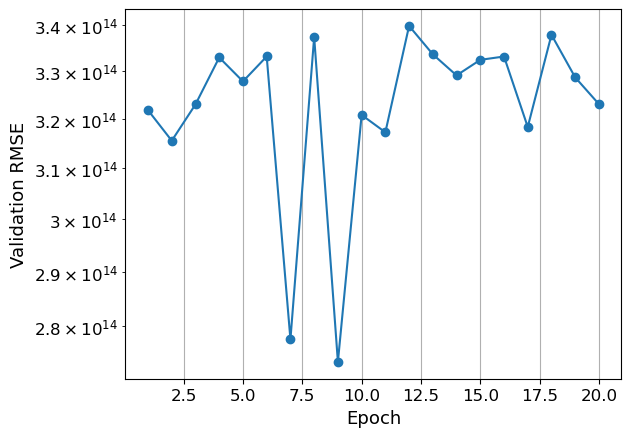

In [35]:
plt.plot(raw_history["Epoch"], raw_history["Validation RMSE"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")
plt.yscale("log")
plt.grid()
plt.show()

### 프로젝트 기록 ③ — 전처리 없는 SGD

실행 결과를 바탕으로 작성한다.

- 첫 번째 에포크의 검증 RMSE:
- 마지막 에포크의 검증 RMSE:
- 마지막 에포크의 최대 절대 가중치:
- RMSE는 감소하는가, 증가하는가, 또는 매우 큰 값에서 불안정한가?:
- 이 결과를 **경사하강법의 발산**이라고 볼 수 있는가? 그 이유는?:
- 특성 크기와 gradient를 이용하여 결과를 설명한다:

### AI 체크포인트 ② — 발산 원인 검토

`raw_history`와 특성 요약표를 AI에게 보여 주고
왜 이런 결과가 나타났는지 설명을 요청해도 된다.

직접 확인할 점은 다음과 같다.

- 단순히 “성능이 나쁘다”가 아니라 **학습 과정이 안정적인지** 구분했는가?
- 큰 특성값 → 큰 gradient → 큰 업데이트의 연결이 설명되어 있는가?
- 학습률 `0.0001`이 언제나 큰 학습률이라고 일반화하지 않았는가?
- 데이터 스케일이 달라지면 적절한 학습률도 달라질 수 있다는 점을 고려했는가?

### 표준화한 데이터로 다시 학습한다

`StandardScaler`를 사용하여 각 특성의 평균을 0,
표준편차를 1에 가깝게 맞춘다.

$$
z=\frac{x-\mu}{\sigma}
$$

`StandardScaler`는 학습 데이터에만 `fit()`한다.
검증 데이터에는 학습 데이터에서 구한 평균과 표준편차를 그대로 사용한다.

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

pd.DataFrame(X_train_scaled, columns=X_train.columns).describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,12384.0,2.045450e-16,1.00004,-1.784906,-0.692520,-0.168412,0.460930,5.894629
HouseAge,12384.0,1.250794e-16,1.00004,-2.188039,-0.839642,0.032850,0.667390,1.857152
AveRooms,12384.0,5.726112e-16,1.00004,-2.177216,-0.466290,-0.090842,0.305293,27.149637
AveBedrms,12384.0,-2.252003e-16,1.00004,-1.982651,-0.238506,-0.118691,0.021932,28.508417
Population,12384.0,4.819573e-17,1.00004,-1.248356,-0.558569,-0.225508,0.261812,30.023430
AveOccup,12384.0,-1.491773e-17,1.00004,-0.330918,-0.085648,-0.030682,0.034881,84.346982
Latitude,12384.0,-2.731665e-15,1.00004,-1.446345,-0.803421,-0.648556,0.975178,2.960263
Longitude,12384.0,-7.170836e-15,1.00004,-2.379141,-1.107318,0.538570,0.782960,2.628350


원본 실험과 **같은 SGD 설정과 같은 학습률**로 다시 학습한다.

In [37]:
sgd_scaled, scaled_history = train_by_epoch(X_train_scaled, y_train, X_val_scaled, y_val)

scaled_history

,Epoch,Train RMSE,Validation RMSE,Max |weight|
0,1,1.025659,1.034419,0.541854
1,2,0.806438,0.814020,0.700173
2,3,0.773307,0.780864,0.757557
3,4,0.761150,0.768718,0.785572
4,5,0.752730,0.760408,0.803666
5,6,0.746094,0.753973,0.817450
6,7,0.740767,0.748903,0.828711
7,8,0.736474,0.744894,0.838133
8,9,0.733009,0.741718,0.846064
9,10,0.730206,0.739200,0.852734


전처리 전과 표준화 후의 검증 RMSE 변화를 함께 비교한다.

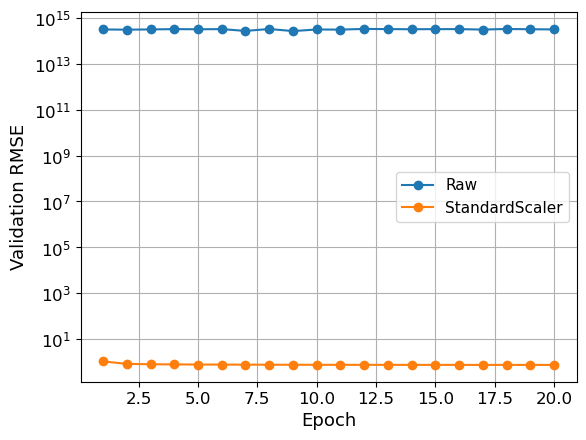

In [38]:
plt.plot(raw_history["Epoch"], raw_history["Validation RMSE"], marker="o", label="Raw")
plt.plot(scaled_history["Epoch"], scaled_history["Validation RMSE"], marker="o", label="StandardScaler")

plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

### 프로젝트 기록 ④ — 표준화의 효과

다음을 작성한다.

- 표준화 후 첫 번째 에포크의 검증 RMSE:
- 표준화 후 마지막 에포크의 검증 RMSE:
- 표준화 전과 후의 가중치 크기는 어떻게 다른가?:
- 같은 학습률을 사용했는데 학습 결과가 달라진 이유:
- **표준화가 예측 문제 자체를 바꾼 것인가, 아니면 경사하강법이 학습하기 쉬운 형태로 만든 것인가?**
- 표준화가 SGD에서 중요한 이유를 3~5문장으로 설명한다.

### 로그 변환 후 표준화한다

표준화는 특성들의 **척도**를 맞추는 역할을 한다.

이번에는 일부 특성의 분포도 바꾸어 본다.
큰 값이나 극단적인 값의 영향을 완화하기 위해 다음 특성에 `log1p()`를 적용한다.

- `MedInc`
- `AveRooms`
- `AveBedrms`
- `Population`
- `AveOccup`

그 다음 모든 특성을 표준화한다.

이 실험은 표준화만 적용한 결과보다 추가적인 개선이 있는지 확인하기 위한 것이다.

In [39]:
log_features = ["MedInc", "AveRooms", "AveBedrms", "Population", "AveOccup"]

X_train[log_features].skew().sort_values(ascending=False)

AveOccup      76.928616
AveBedrms     14.726266
AveRooms       9.176753
Population     5.821331
MedInc         1.589472
dtype: float64

### 나만의 분포 확인

로그 변환 대상 중 하나를 선택하여 원래 값과 로그 변환 값을 비교한다.

`feature_to_check`를 원하는 특성으로 바꾸어도 된다.

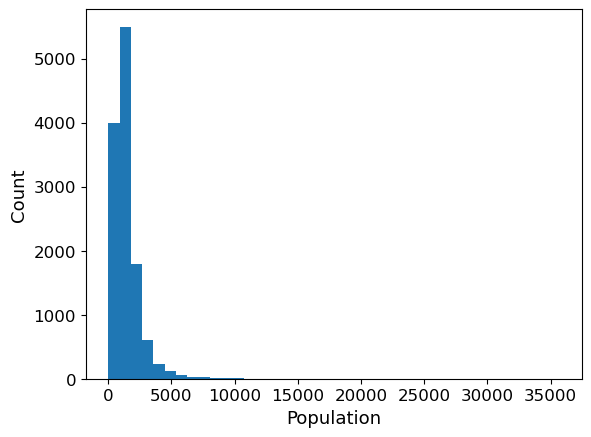

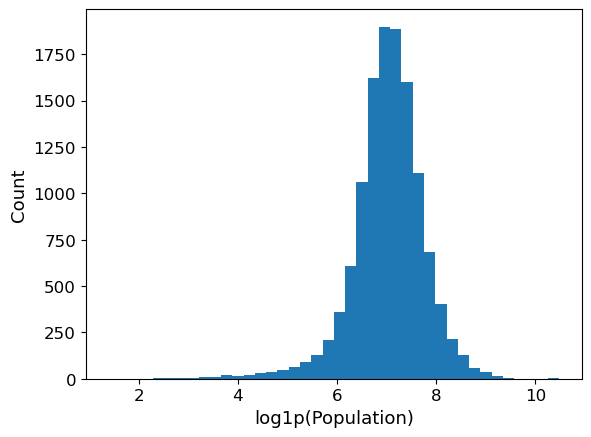

In [40]:
feature_to_check = "Population"  # TODO: 다른 로그 변환 대상 특성으로 변경 가능

plt.hist(X_train[feature_to_check], bins=40)
plt.xlabel(feature_to_check)
plt.ylabel("Count")
plt.show()

plt.hist(np.log1p(X_train[feature_to_check]), bins=40)
plt.xlabel(f"log1p({feature_to_check})")
plt.ylabel("Count")
plt.show()

### 프로젝트 기록 ⑤ — 로그 변환 전 가설

- 선택한 특성:
- 원래 분포의 특징:
- 로그 변환 후 분포의 특징:
- 큰 값들의 간격이 어떻게 달라졌는가?:
- 로그 변환 후 `SGDRegressor`의 검증 RMSE가 더 좋아질 것으로 예상하는가? 그 이유는?:

> 나의 가설:

In [41]:
def apply_log_transform(X):
    X_transformed = X.copy()
    X_transformed[log_features] = np.log1p(X_transformed[log_features])
    return X_transformed

X_train_log = apply_log_transform(X_train)
X_val_log = apply_log_transform(X_val)

log_scaler = StandardScaler()

X_train_log_scaled = log_scaler.fit_transform(X_train_log)
X_val_log_scaled = log_scaler.transform(X_val_log)

다시 같은 SGD 설정과 같은 학습률을 사용한다.

In [42]:
sgd_log_scaled, log_scaled_history = train_by_epoch(X_train_log_scaled, y_train, X_val_log_scaled, y_val)

log_scaled_history

,Epoch,Train RMSE,Validation RMSE,Max |weight|
0,1,1.013300,1.025917,0.504373
1,2,0.788196,0.797373,0.656258
2,3,0.751365,0.758056,0.724958
3,4,0.737998,0.742970,0.766870
4,5,0.729789,0.733556,0.796377
5,6,0.724068,0.726974,0.818186
6,7,0.719933,0.722221,0.834428
7,8,0.716873,0.718713,0.846401
8,9,0.714554,0.716070,0.855036
9,10,0.712754,0.714039,0.861050


세 실험의 마지막 결과를 비교한다.

In [43]:
comparison = pd.DataFrame({
    "Input": ["Raw", "StandardScaler", "Log + StandardScaler"],
    "Validation RMSE": [
        raw_history["Validation RMSE"].iloc[-1],
        scaled_history["Validation RMSE"].iloc[-1],
        log_scaled_history["Validation RMSE"].iloc[-1]
    ],
    "Max |weight|": [
        raw_history["Max |weight|"].iloc[-1],
        scaled_history["Max |weight|"].iloc[-1],
        log_scaled_history["Max |weight|"].iloc[-1]
    ]
})

comparison

,Input,Validation RMSE,Max |weight|
0,Raw,3.230365e+14,4.296178e+11
1,StandardScaler,7.301831e-01,8.786252e-01
2,Log + StandardScaler,7.064341e-01,8.593950e-01


에포크에 따른 검증 RMSE도 함께 확인한다.

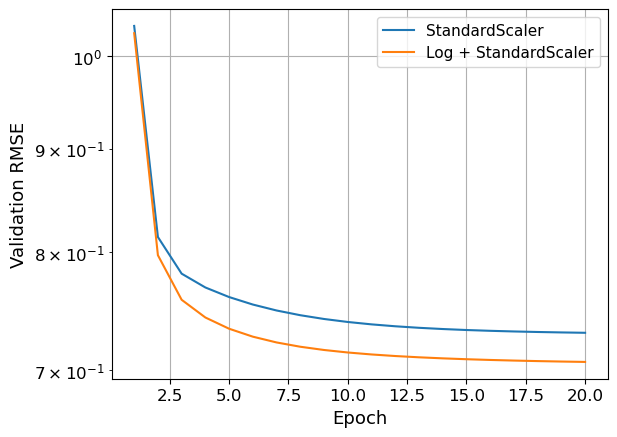

In [44]:
plt.plot(scaled_history["Epoch"], scaled_history["Validation RMSE"], label="StandardScaler")
plt.plot(log_scaled_history["Epoch"], log_scaled_history["Validation RMSE"], label="Log + StandardScaler")

plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

### 프로젝트 기록 ⑥ — 세 실험 비교와 최종 선택

다음을 작성한다.

- 원본 데이터의 검증 RMSE:
- 표준화 데이터의 검증 RMSE:
- 로그 변환 + 표준화 데이터의 검증 RMSE:
- 원본과 표준화의 차이를 **경사하강법의 안정성** 관점에서 설명한다:
- 표준화와 로그 변환 + 표준화의 차이를 **예측 성능** 관점에서 설명한다:
- 로그 변환이 추가적인 개선을 만들었다면 가능한 이유는 무엇인가?:
- 로그 변환이 반드시 모든 특성과 모든 문제에서 좋은가?:
- 최종 모델에 사용할 입력 방식:
- 최종 선택 근거를 3~5문장으로 작성한다.

### AI 체크포인트 ③ — 세 실험 해석 검토

`comparison`과 RMSE 그래프, 자신의 선택 근거를 AI에게 보여 주고 검토를 요청해도 된다.

직접 확인할 점은 다음과 같다.

- 원본 모델의 문제를 단순히 “정확도가 낮다”라고 표현하지 않았는가?
- 표준화의 효과와 로그 변환의 효과를 구분하여 설명했는가?
- 로그 변환 + 표준화가 가장 좋았다고 해서 로그 변환 자체가 항상 좋은 방법이라고 일반화하지 않았는가?
- 최종 테스트 결과를 보기 전에 입력 방식을 선택했는가?

**수정하거나 받아들이지 않은 AI의 제안과 그 이유**

> 작성:

### 최종 입력 방식을 확정한다

검증 결과와 자신의 판단에 따라 아래 값을 수정한다.

- `"scaled"`: 표준화만 사용
- `"log_scaled"`: 로그 변환 후 표준화

In [45]:
final_preprocessing = "log_scaled"  # TODO: 검증 결과와 자신의 판단에 따라 수정

assert final_preprocessing in ["scaled", "log_scaled"]

print("최종 입력 방식:", final_preprocessing)

최종 입력 방식: log_scaled


### 2단계 마무리 체크

다음을 설명할 수 있는지 확인한다.

- 배치 경사하강법과 SGD의 차이
- SGD에서 한 에포크의 의미
- 학습률의 역할
- 특성 스케일이 gradient와 업데이트에 영향을 주는 이유
- 원본 데이터에서 SGD가 불안정해질 수 있는 이유
- 표준화가 경사하강법의 학습을 안정화하는 이유
- 로그 변환과 표준화의 역할이 서로 다른 이유
- 검증 데이터에서 최종 입력 방식을 선택해야 하는 이유

## 3단계 — 최종 모델을 평가하고 해석한다

### 개발 데이터 전체로 다시 훈련한다

최종 입력 방식을 선택했으므로 학습용과 검증용을 합친 개발 데이터 전체를 사용한다.

최종 테스트 데이터의 변환에는
**개발 데이터에서 학습한 변환 정보만 사용한다.**

In [46]:
if final_preprocessing == "scaled":
    final_scaler = StandardScaler()
    X_dev_final = final_scaler.fit_transform(X_dev)
    X_test_final = final_scaler.transform(X_test)

else:
    X_dev_log = apply_log_transform(X_dev)
    X_test_log = apply_log_transform(X_test)

    final_scaler = StandardScaler()
    X_dev_final = final_scaler.fit_transform(X_dev_log)
    X_test_final = final_scaler.transform(X_test_log)

세 실험과 동일하게 학습률 `0.0001`을 사용하고
개발 데이터 전체를 20 epoch 학습한다.

In [47]:
final_model = make_sgd()

for epoch in range(EPOCHS):
    final_model.partial_fit(X_dev_final, y_dev)

test_pred = final_model.predict(X_test_final)
test_rmse = root_mean_squared_error(y_test, test_pred)

print("최종 테스트 RMSE:", test_rmse)
print("달러 기준 대략적인 RMSE:", test_rmse * 100_000)

최종 테스트 RMSE: 0.7152987907895275
달러 기준 대략적인 RMSE: 71529.87907895276


### 프로젝트 기록 ⑦ — 최종 성능 해석

숫자를 그대로 옮기지 말고 의미를 설명한다.

- 최종 선택한 입력 방식:
- 검증 RMSE:
- 최종 테스트 RMSE:
- 달러 기준으로 환산한 RMSE:
- 검증 결과와 최종 테스트 결과는 얼마나 비슷하거나 다른가?:
- 테스트 RMSE가 의미하는 바를 실제 주택 가격 예측의 언어로 설명한다:
- 최종 결과만 보고 SGD가 항상 좋은 회귀 방법이라고 말할 수 있는가?:

### 학습 안정성과 예측 성능을 구분한다

이번 프로젝트에서 두 가지 판단을 구분하는 것이 중요하다.

**학습 안정성**

> 경사하강법이 손실을 줄이는 방향으로 정상적으로 파라미터를 학습하고 있는가?

**예측 성능**

> 안정적으로 학습된 여러 방법 중 어느 것이 검증 데이터에서 더 작은 예측 오차를 보이는가?

원본 데이터에서 RMSE가 폭발하는 문제는 주로 **학습 안정성**의 문제다.

표준화와 로그 변환 + 표준화 사이의 차이는
안정적으로 학습된 상태에서 **예측 성능**을 비교하는 문제에 가깝다.

### 분석의 한계를 생각한다

다음을 포함하여 두 가지 이상의 한계를 작성한다.

- 하나의 학습률만 사용했다는 점
- 하나의 데이터 분할과 `random_state`만 사용했다는 점
- 선형 회귀 모델만 사용했다는 점
- 로그 변환할 특성을 미리 정했다는 점
- 지역 정보가 포함된 데이터를 무작위 분할했다는 점

위 항목을 그대로 복사하지 말고,
이번 분석 결과를 해석할 때 왜 중요한지 설명한다.

### AI 체크포인트 ④ — 최종 해석 검토

최종 테스트 결과와 자신의 결론을 AI에게 보여 주고 검토를 요청해도 된다.

직접 확인한다.

- 테스트 결과를 본 뒤 전처리 방식을 다시 바꾸지 않았는가?
- 발산과 단순한 성능 저하를 구분했는가?
- 표준화가 모든 모델의 성능을 반드시 높인다고 일반화하지 않았는가?
- 로그 변환이 항상 필요하다고 단정하지 않았는가?
- 검증 RMSE와 테스트 RMSE의 역할을 혼동하지 않았는가?
- 분석의 한계를 구체적으로 적었는가?

**수정하거나 받아들이지 않은 AI의 제안과 그 이유**

> 작성:

### 최종 결론을 작성한다

다음 내용을 포함한다.

- **분석 질문에 대한 답**
- 원본 특성에서 SGD가 어떻게 학습되었는지
- 원본 특성의 크기가 gradient와 가중치 업데이트에 미친 영향
- 표준화 후 학습 과정이 어떻게 달라졌는지
- 로그 변환 + 표준화의 추가 효과
- 최종 입력 방식과 선택 근거
- 검증 RMSE와 최종 테스트 RMSE의 의미
- 이번 프로젝트에서 확인한 경사하강법의 핵심 원리
- 분석의 한계 두 가지 이상
- 다음 분석에서 추가로 확인할 내용

### 프로젝트 최종 제출 전 확인

- [ ] 예측 대상과 회귀 문제의 의미를 설명했다.
- [ ] 학습·검증·테스트 데이터를 구분했다.
- [ ] 특성별 크기 차이를 확인하고 학습 가설을 작성했다.
- [ ] SGD의 파라미터 업데이트와 특성 크기의 관계를 설명했다.
- [ ] 전처리 없이 SGD의 에포크별 RMSE를 확인했다.
- [ ] 발산과 단순한 성능 저하를 구분하여 해석했다.
- [ ] 표준화 후 같은 학습률로 다시 학습했다.
- [ ] 로그 변환 + 표준화 결과를 추가로 비교했다.
- [ ] 검증 결과를 근거로 최종 입력 방식을 선택했다.
- [ ] 최종 테스트셋은 마지막 평가에서만 사용했다.
- [ ] 최종 RMSE를 실제 문제의 언어로 해석했다.
- [ ] AI의 제안을 검토한 근거를 남겼다.
- [ ] 분석의 한계를 두 가지 이상 작성했다.

### 평가 기준

| 영역 | 배점 | 확인할 내용 |
|---|---:|---|
| 문제와 데이터 이해 | 3 | 타깃·회귀 문제·데이터 분할·특성 크기를 적절히 이해했는가? |
| 경사하강법 이해 | 5 | gradient·학습률·에포크·SGD·발산을 실제 결과와 연결하여 설명했는가? |
| 전처리 실험 | 4 | 원본·표준화·로그 변환+표준화를 같은 조건에서 비교하고 차이를 적절히 해석했는가? |
| 검증과 최종 선택 | 3 | 검증 데이터를 이용하여 최종 입력 방식을 선택하고 테스트셋을 보존했는가? |
| 결과 해석과 한계 | 3 | RMSE를 실제 문제의 언어로 설명하고 분석의 한계를 구체적으로 제시했는가? |
| AI 활용과 판단 근거 | 2 | AI의 제안을 검토하고 자신의 판단 근거를 남겼는가? |
| **합계** | **20** | |

## 선택 활동 — 학습률을 바꾸면 어떻게 될까?

본문에서는 전처리 효과를 비교하기 위해 모든 실험에서 학습률을 `0.0001`로 고정했다.

표준화한 데이터를 사용하여 다른 학습률을 하나 선택해 실험해 본다.

- 너무 작은 학습률에서는 어떤 일이 생기는가?
- 너무 큰 학습률에서는 어떤 일이 생기는가?
- P3 실습에서 확인했던 학습률의 역할과 같은 현상이 나타나는가?

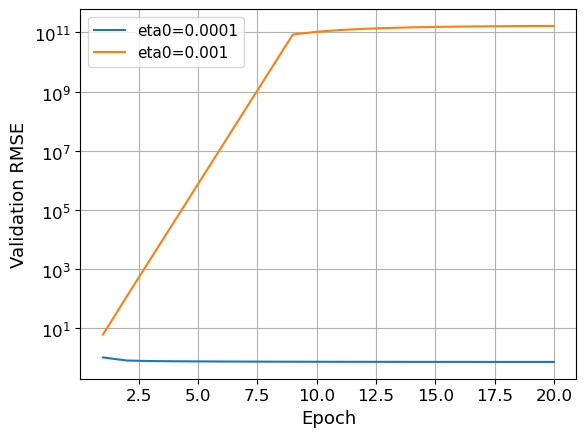

In [48]:
alternative_eta0 = 0.001  # TODO: 다른 학습률로 변경

alternative_model = SGDRegressor(loss="squared_error", penalty=None, learning_rate="constant", eta0=alternative_eta0, random_state=42)
alternative_history = []

for epoch in range(1, EPOCHS + 1):
    alternative_model.partial_fit(X_train_scaled, y_train)
    alternative_pred = alternative_model.predict(X_val_scaled)
    alternative_rmse = root_mean_squared_error(y_val, alternative_pred)
    alternative_history.append({"Epoch": epoch, "Validation RMSE": alternative_rmse})

alternative_history = pd.DataFrame(alternative_history)

plt.plot(scaled_history["Epoch"], scaled_history["Validation RMSE"], label=f"eta0={ETA0}")
plt.plot(alternative_history["Epoch"], alternative_history["Validation RMSE"], label=f"eta0={alternative_eta0}")

plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()